In [3]:
"""
===============================================================================
PART 3C (OPTIMIZED): FAST QUANTUM TRAJECTORY NOISE SWEEP (C++ LIGHTNING)
Script: run_fast_noise_robustness.py
===============================================================================
- Simulates depolarizing noise via Stochastic Pauli Errors on lightning.qubit.
- Runs 10,000x faster than default.mixed (completes in ~2-3 minutes total).
- Grid: n in {8, 10, 12}, k in {2, 4, 6, 8, 10, 12} (k <= n).
- Noise levels: p in {0.000, 0.005, 0.010, 0.020}, Depths: L = 1 to 20.
- Outputs: noise_variance_curves.csv, summary_3c_noise_robustness.csv
===============================================================================
"""
!pip install pennylane
import os
import sys
import time
import datetime
import warnings
import csv
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

# 1. MOUNT GOOGLE DRIVE
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = "/content/drive/MyDrive/QML_Research"
    os.makedirs(DRIVE_DIR, exist_ok=True)
    CSV_NOISE_RAW = os.path.join(DRIVE_DIR, "noise_variance_curves.csv")
    CSV_NOISE_SUMMARY = os.path.join(DRIVE_DIR, "summary_3c_noise_robustness.csv")
    print(f"Persistent storage verified: {DRIVE_DIR}")
except Exception:
    CSV_NOISE_RAW = "noise_variance_curves.csv"
    CSV_NOISE_SUMMARY = "summary_3c_noise_robustness.csv"
    print("Running locally / Drive unavailable. Saving to current directory.")

try:
    import pennylane as qml
    from pennylane import numpy as pnp
except ImportError:
    raise ImportError("PennyLane is required. Run: !pip install pennylane pennylane-lightning")

warnings.filterwarnings("ignore")

GLOBAL_SEED = 42
MAX_DEPTH = 20
N_PARAM_SETS = 20

SYSTEMS = [8, 10, 12]
K_CANDIDATES = [2, 4, 6, 8, 10, 12]
NOISE_LEVELS = [0.000, 0.005, 0.010, 0.020]

CSV_HEADERS = [
    "framework",
    "framework_version",
    "noise_type",
    "noise_prob",
    "n",
    "k",
    "depth",
    "n_params",
    "n_param_sets",
    "n_grad_components",
    "var_pooled",
    "seed",
    "wall_time_s",
    "timestamp"
]

def build_noisy_brickwall(n_qubits, depth, params, p_noise, rng_noise):
    param_idx = 0
    for d in range(depth):
        for q in range(n_qubits):
            qml.RY(params[param_idx], wires=q)
            param_idx += 1

        if d % 2 == 0:
            for q in range(0, n_qubits - 1, 2):
                qml.CNOT(wires=[q, q + 1])
                if p_noise > 0.0:
                    for target_wire in [q, q + 1]:
                        r = rng_noise.random()
                        if r < p_noise / 3.0:
                            qml.PauliX(wires=target_wire)
                        elif r < 2.0 * p_noise / 3.0:
                            qml.PauliY(wires=target_wire)
                        elif r < p_noise:
                            qml.PauliZ(wires=target_wire)
        else:
            for q in range(1, n_qubits - 1, 2):
                qml.CNOT(wires=[q, q + 1])
                if p_noise > 0.0:
                    for target_wire in [q, q + 1]:
                        r = rng_noise.random()
                        if r < p_noise / 3.0:
                            qml.PauliX(wires=target_wire)
                        elif r < 2.0 * p_noise / 3.0:
                            qml.PauliY(wires=target_wire)
                        elif r < p_noise:
                            qml.PauliZ(wires=target_wire)

def build_pauli_z_observable(k):
    obs = qml.PauliZ(0)
    for q in range(1, k):
        obs = obs @ qml.PauliZ(q)
    return obs

def get_cell_seed(global_seed, p_idx, n, k, depth):
    val = (global_seed * 1000003 + p_idx * 50021 + n * 10007 + k * 1009 + depth * 31) & 0x7FFFFFFF
    return int(val)

def run_fast_noise_simulation():
    pennylane_version = qml.__version__

    with open(CSV_NOISE_RAW, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(CSV_HEADERS)

    grid_cells = [(n, k) for n in SYSTEMS for k in K_CANDIDATES if k <= n]
    total_points = len(NOISE_LEVELS) * len(grid_cells) * MAX_DEPTH

    print("=" * 80)
    print("STARTING OPTIMIZED NOISE SWEEP (LIGHTNING QUANTUM TRAJECTORIES)")
    print(f"Total Points: {total_points} | Depths: {MAX_DEPTH} | Noise Levels: {NOISE_LEVELS}")
    print("=" * 80)

    global_start = time.time()
    points_done = 0

    for p_idx, p_noise in enumerate(NOISE_LEVELS):
        for n, k in grid_cells:
            dev = qml.device("lightning.qubit", wires=n)
            obs = build_pauli_z_observable(k)

            for depth in range(1, MAX_DEPTH + 1):
                cell_start = time.time()
                n_params = depth * n
                cell_seed = get_cell_seed(GLOBAL_SEED, p_idx, n, k, depth)
                rng_noise = np.random.default_rng(cell_seed)
                pnp.random.seed(cell_seed)

                @qml.qnode(dev, diff_method="adjoint")
                def circuit(params):
                    build_noisy_brickwall(n, depth, params, p_noise, rng_noise)
                    return qml.expval(obs)

                grad_fn = qml.grad(circuit)
                grad_matrix = np.empty((N_PARAM_SETS, n_params), dtype=np.float64)

                for s in range(N_PARAM_SETS):
                    params_s = pnp.random.uniform(0.0, 2.0 * np.pi, size=n_params, requires_grad=True)
                    grad_vec = grad_fn(params_s)
                    grad_matrix[s, :] = np.array(grad_vec, dtype=np.float64).flatten()

                all_grads = grad_matrix.flatten()
                var_pooled = float(np.var(all_grads))
                n_grad_components = N_PARAM_SETS * n_params
                wall_time = time.time() - cell_start
                iso_time = datetime.datetime.now(datetime.timezone.utc).isoformat()

                with open(CSV_NOISE_RAW, mode="a", newline="", encoding="utf-8") as f:
                    writer = csv.writer(f)
                    writer.writerow([
                        "pennylane-lightning.qubit",
                        pennylane_version,
                        "stochastic_depolarizing",
                        p_noise,
                        n,
                        k,
                        depth,
                        n_params,
                        N_PARAM_SETS,
                        n_grad_components,
                        f"{var_pooled:.8e}",
                        cell_seed,
                        f"{wall_time:.3f}",
                        iso_time
                    ])
                    f.flush()
                    os.fsync(f.fileno())

                points_done += 1

                if points_done % 10 == 0 or depth == MAX_DEPTH:
                    elapsed = time.time() - global_start
                    avg_t = elapsed / points_done
                    rem_s = int(avg_t * (total_points - points_done))
                    print(
                        f"[p={p_noise:.3f} | ({n:2d}, {k:2d}) | Depth {depth:2d}/{MAX_DEPTH}] "
                        f"Var: {var_pooled:.4e} | Time: {wall_time:5.2f}s | "
                        f"Progress: {points_done:3d}/{total_points} | "
                        f"Est. Rem: {str(datetime.timedelta(seconds=rem_s))}"
                    )

def run_noise_analysis(threshold=1e-2):
    df_raw = pd.read_csv(CSV_NOISE_RAW)
    df_raw['var_pooled'] = df_raw['var_pooled'].astype(float)
    df_raw['noise_prob'] = df_raw['noise_prob'].astype(float)
    df_raw['n'] = df_raw['n'].astype(int)
    df_raw['k'] = df_raw['k'].astype(int)
    df_raw['depth'] = df_raw['depth'].astype(int)

    summary_rows = []

    for p_val, grp in df_raw.groupby('noise_prob'):
        tau_rows = []
        for (n, k), cell_g in grp.groupby(['n', 'k']):
            sorted_g = cell_g.sort_values('depth')
            cr = sorted_g[sorted_g['var_pooled'] < threshold]
            if len(cr) > 0:
                tau = int(cr.iloc[0]['depth'])
                censored = False
            else:
                tau = MAX_DEPTH + 1
                censored = True
            tau_rows.append({'n': n, 'k': k, 'nk': n * k, 'tau': tau, 'censored': censored})

        tau_df = pd.DataFrame(tau_rows)
        clean_df = tau_df[~tau_df['censored']].copy()

        if len(clean_df) >= 3:
            Y = np.log(clean_df['tau'])
            X = sm.add_constant(np.log(clean_df['nk']))
            model = sm.OLS(Y, X).fit()
            A_val = float(np.exp(model.params.iloc[0]))
            c_val = float(-model.params.iloc[1])
            preds = A_val * (clean_df['nk'] ** (-c_val))
            r2_val = float(r2_score(clean_df['tau'], preds))
            mae_val = float(mean_absolute_error(clean_df['tau'], preds))
            mape_val = float(np.mean(np.abs((clean_df['tau'] - preds) / clean_df['tau'])) * 100)
        else:
            A_val, c_val, r2_val, mae_val, mape_val = np.nan, np.nan, np.nan, np.nan, np.nan

        summary_rows.append({
            "noise_prob": p_val,
            "A(p)": A_val,
            "c(p)": c_val,
            "R2": r2_val,
            "MAE": mae_val,
            "MAPE(%)": mape_val,
            "N_obs": len(clean_df),
            "N_cens": int(tau_df['censored'].sum())
        })

    summary_df = pd.DataFrame(summary_rows)
    print("\n" + "=" * 80)
    print("SUMMARY 3C: NOISE ROBUSTNESS SCALING SUMMARY")
    print("=" * 80)
    print(summary_df.to_string(index=False))
    summary_df.to_csv(CSV_NOISE_SUMMARY, index=False)
    print(f"\nSaved summary to: {os.path.abspath(CSV_NOISE_SUMMARY)}")

if __name__ == "__main__":
    run_fast_noise_simulation()
    run_noise_analysis()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Persistent storage verified: /content/drive/MyDrive/QML_Research
STARTING OPTIMIZED NOISE SWEEP (LIGHTNING QUANTUM TRAJECTORIES)
Total Points: 1200 | Depths: 20 | Noise Levels: [0.0, 0.005, 0.01, 0.02]
[p=0.000 | ( 8,  2) | Depth 10/20] Var: 2.9242e-02 | Time:  0.28s | Progress:  10/1200 | Est. Rem: 0:03:53
[p=0.000 | ( 8,  2) | Depth 20/20] Var: 1.0746e-02 | Time:  0.52s | Progress:  20/1200 | Est. Rem: 0:06:29
[p=0.000 | ( 8,  4) | Depth 10/20] Var: 1.5430e-02 | Time:  0.45s | Progress:  30/1200 | Est. Rem: 0:05:55
[p=0.000 | ( 8,  4) | Depth 20/20] Var: 6.9864e-03 | Time:  0.58s | Progress:  40/1200 | Est. Rem: 0:07:23
[p=0.000 | ( 8,  6) | Depth 10/20] Var: 7.3956e-03 | Time:  0.29s | Progress:  50/1200 | Est. Rem: 0:06:43
[p=0.000 | ( 8,  6) | Depth 20/20] Var: 4.9042e-03 | Time:  0.67s | Progress:  60/1200 | Est. Rem: 0:07:06
[p=0.000 | ( 8,  8) | Depth

Loading variance data from disk: variance_curves.csv
Successfully harmonized 40 variance curves.
Example Key: ('brickwall', np.int64(8), np.int64(2)) -> Max Depth: 30
Initial 3 variance points: [0.05837226 0.06415188 0.04670966]
Baseline Threshold: 0.01
Sweep Thresholds: [0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
Max circuit depth detected: 30 (Censored tau marker = 31)
Computed 280 total tau records across 7 thresholds.

Censoring Report per Threshold:
  Threshold  1e-01:  0/40 censored. Configs: None 
  Threshold  5e-02:  0/40 censored. Configs: None 
  Threshold  1e-02:  0/40 censored. Configs: None 
  Threshold  5e-03:  1/40 censored. Configs: ['(n=8, k=2)'] 
  Threshold  1e-03: 20/40 censored. Configs: ['(n=8, k=2)', '(n=8, k=3)', '(n=8, k=4)', '(n=8, k=5)'] ...
  Threshold  5e-04: 26/40 censored. Configs: ['(n=8, k=2)', '(n=8, k=3)', '(n=8, k=4)', '(n=8, k=5)'] ...
  Threshold  1e-04: 33/40 censored. Configs: ['(n=8, k=2)', '(n=8, k=3)', '(n=8, k=4)', '(n=8, k=5)'] ...

    

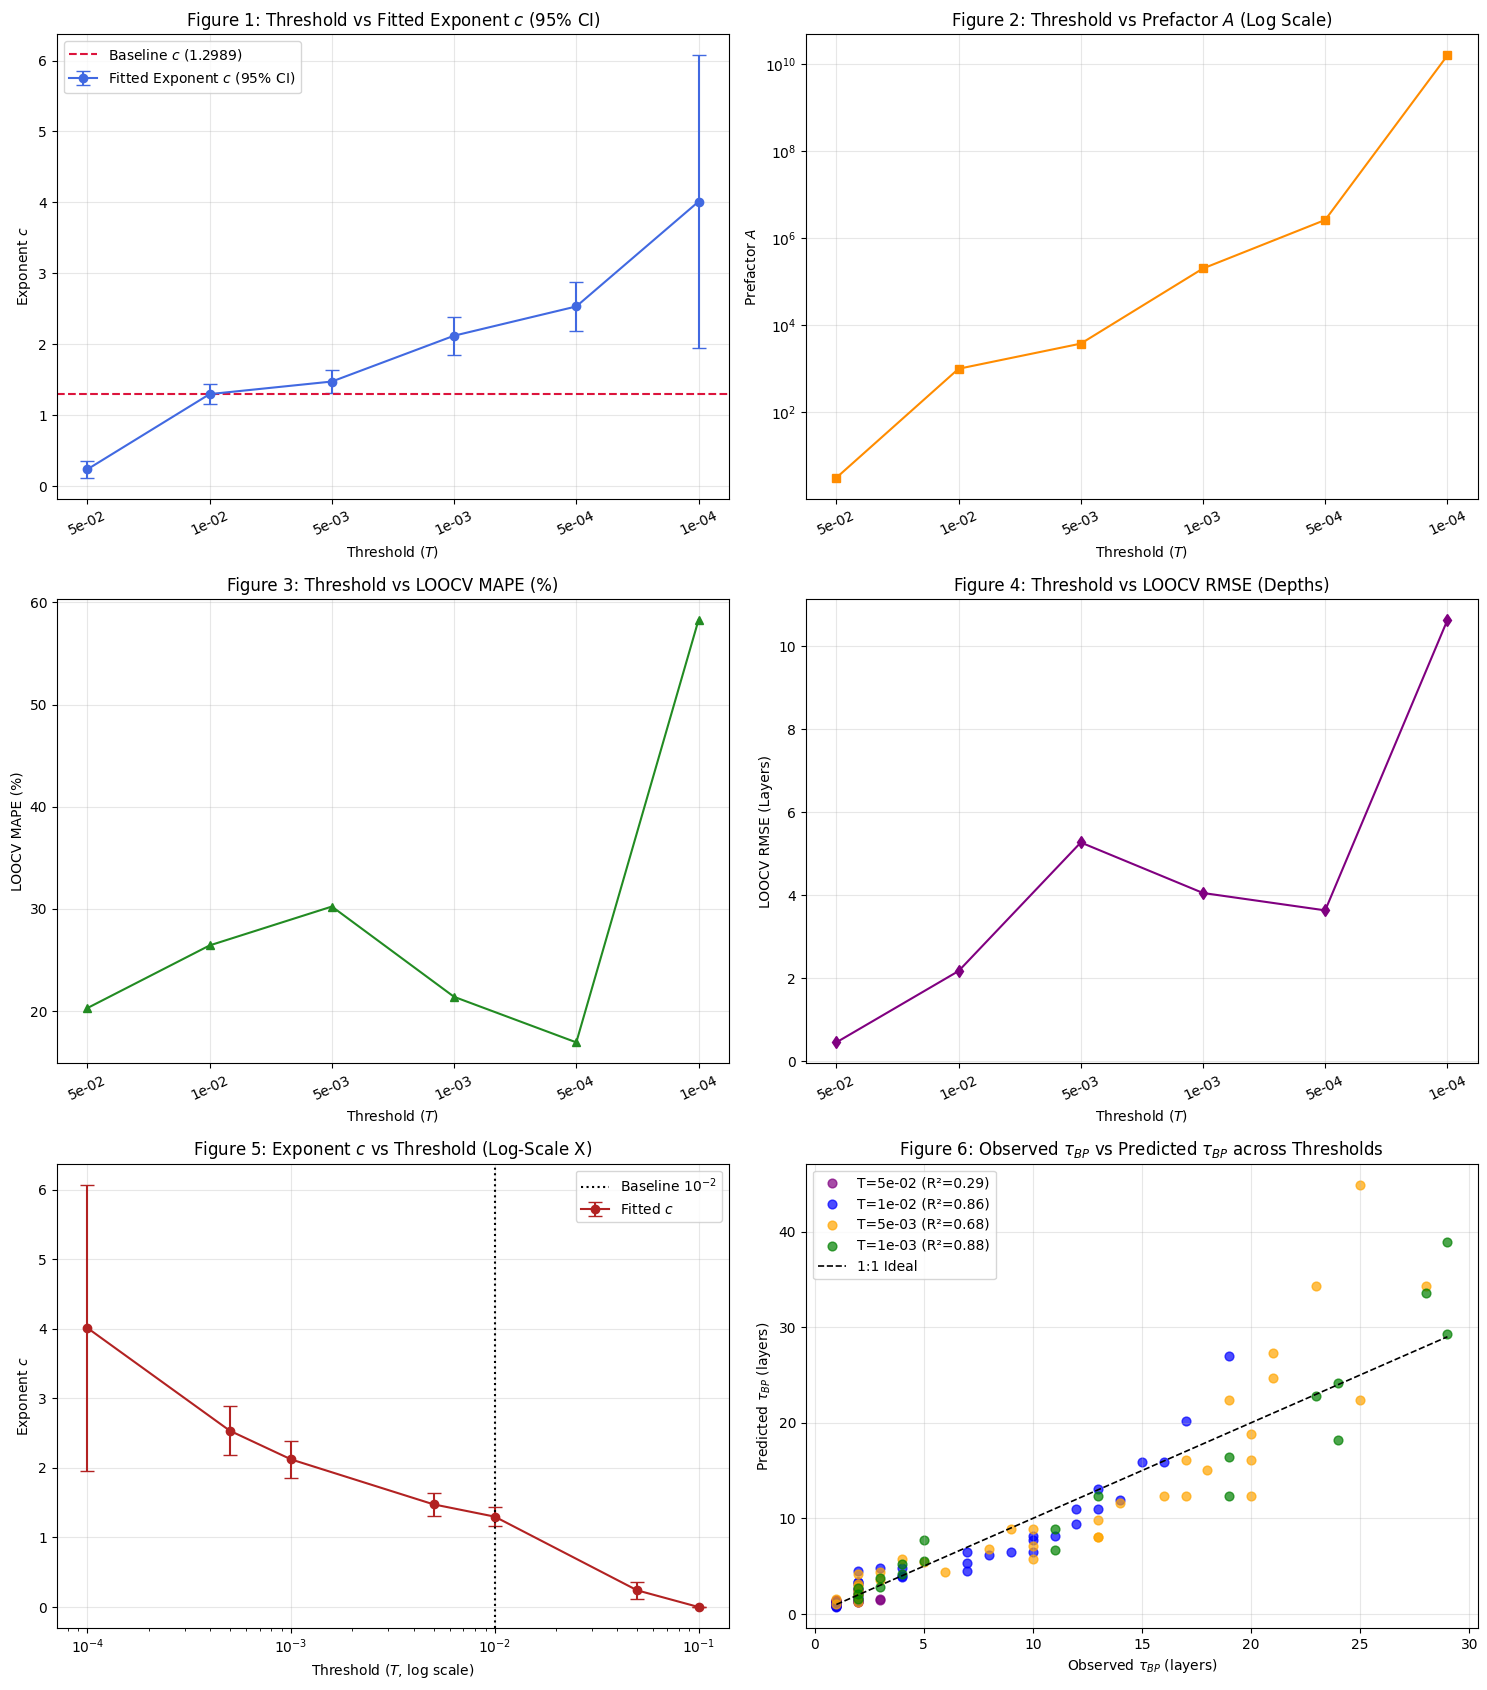

THRESHOLD ROBUSTNESS SUMMARY
Baseline threshold = 1e-02
Baseline A = 988.5995
Baseline c = 1.2989

Minimum c = -0.0000 (at T = 1e-01)
Maximum c = 4.0113 (at T = 1e-04)
Relative c range = 308.82 %
Number of thresholds supporting stable exponent = 1/7

Conclusion: THRESHOLD-DEPENDENT
CASE C: The power-law scaling breaks down or shifts dramatically across the tested span. The predictive claim must be framed strictly around specific variance thresholds.

Files successfully saved:
  - threshold_robustness_results.csv
  - threshold_tau_dataset.csv
  - threshold_robustness_checkpoint.pkl


In [1]:
# ==============================================================================
# CELL 1: Imports, Dependencies, and Loading Stored Variance Curves
# ==============================================================================
import os
import glob
import pickle
import json
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

POSSIBLE_FILES = [
    "variance_curves.csv",
    "variance_curves.pkl",
    "variance_curves.json",
    "/content/variance_curves.csv",
    "/content/drive/MyDrive/QML_Research/variance_curves.csv",
    "baseline_variance_curves.pkl"
]

loaded_curves = None

if "variance_curves" in globals():
    loaded_curves = globals()["variance_curves"]
    print("Found 'variance_curves' in runtime memory.")
else:
    for fpath in POSSIBLE_FILES:
        if os.path.exists(fpath):
            print(f"Loading variance data from disk: {fpath}")
            if fpath.endswith(".pkl"):
                with open(fpath, "rb") as f:
                    loaded_curves = pickle.load(f)
            elif fpath.endswith(".json"):
                with open(fpath, "r") as f:
                    loaded_curves = json.load(f)
            elif fpath.endswith(".csv"):
                loaded_curves = pd.read_csv(fpath)
            break

if loaded_curves is None:
    raise FileNotFoundError(
        "CRITICAL ERROR: Raw depth-by-depth variance data is required. "
        "No existing 'variance_curves' variable or supported checkpoint files found. "
        "Halting execution to prevent expensive quantum simulation reruns."
    )

# ==============================================================================
# CELL 2: Inspect and Harmonize Variance-Curve Structure
# ==============================================================================
variance_dict = {}

if isinstance(loaded_curves, dict):
    for key, val in loaded_curves.items():
        if isinstance(key, str) and "(" in key:
            parsed_key = tuple(int(x.strip()) for x in key.strip("()").split(","))
        else:
            parsed_key = key

        if isinstance(val, dict):
            sorted_depths = sorted(val.keys(), key=lambda x: int(x))
            curve = [val[d] for d in sorted_depths]
        else:
            curve = list(val)
        variance_dict[parsed_key] = np.array(curve, dtype=float)

elif isinstance(loaded_curves, pd.DataFrame):
    df = loaded_curves.copy()
    df.columns = [c.lower() for c in df.columns]

    # Detect variance column flexibly
    var_col = None
    for c in ['var_pooled', 'variance', 'var', 'variance_pooled', 'var_mean']:
        if c in df.columns:
            var_col = c
            break
    if var_col is None:
        raise ValueError(f"Could not identify variance column in DataFrame. Found: {df.columns.tolist()}")

    group_cols = [c for c in ['architecture', 'arch', 'n', 'k'] if c in df.columns]
    depth_col = 'depth' if 'depth' in df.columns else 'l'

    for keys, grp in df.groupby(group_cols):
        grp_sorted = grp.sort_values(depth_col)
        variance_dict[keys] = grp_sorted[var_col].values.astype(float)

print(f"Successfully harmonized {len(variance_dict)} variance curves.")
example_key = list(variance_dict.keys())[0]
print(f"Example Key: {example_key} -> Max Depth: {len(variance_dict[example_key])}")
print(f"Initial 3 variance points: {variance_dict[example_key][:3]}")

# ==============================================================================
# CELL 3: Define Threshold Sweep and Baseline Parameters
# ==============================================================================
THRESHOLDS = [
    1e-1,
    5e-2,
    1e-2,   # Baseline
    5e-3,
    1e-3,
    5e-4,
    1e-4
]

BASELINE_THRESHOLD = 1e-2
MAX_DEPTH = max(len(curve) for curve in variance_dict.values())
CENSORED_VALUE = MAX_DEPTH + 1

print(f"Baseline Threshold: {BASELINE_THRESHOLD}")
print(f"Sweep Thresholds: {THRESHOLDS}")
print(f"Max circuit depth detected: {MAX_DEPTH} (Censored tau marker = {CENSORED_VALUE})")

# ==============================================================================
# CELL 4: Compute tau_BP for Every Configuration Across All Thresholds
# ==============================================================================
tau_records = []

for config_key, curve in variance_dict.items():
    if not isinstance(config_key, tuple):
        config_key = (config_key,)

    if len(config_key) == 3:
        arch, n, k = config_key
    elif len(config_key) == 2:
        arch, n, k = "brickwall", config_key[0], config_key[1]
    elif len(config_key) == 4:
        arch, n, k = config_key[0], config_key[2], config_key[3]
    else:
        arch, n, k = "default", config_key[0], config_key[1]

    for T in THRESHOLDS:
        crossings = np.where(curve < T)[0]
        if len(crossings) > 0:
            tau = int(crossings[0] + 1)
            is_censored = False
        else:
            tau = int(CENSORED_VALUE)
            is_censored = True

        tau_records.append({
            "architecture": str(arch),
            "n": int(n),
            "k": int(k),
            "nk": int(n * k),
            "threshold": float(T),
            "is_baseline": bool(T == BASELINE_THRESHOLD),
            "tau": tau,
            "is_censored": is_censored
        })

df_tau_all = pd.DataFrame(tau_records)
print(f"Computed {len(df_tau_all)} total tau records across {len(THRESHOLDS)} thresholds.")

# ==============================================================================
# CELL 5: Build Threshold-Specific Datasets and Quantify Censoring
# ==============================================================================
censoring_summary = {}

for T in THRESHOLDS:
    sub = df_tau_all[df_tau_all["threshold"] == T]
    censored_sub = sub[sub["is_censored"]]
    censoring_summary[T] = {
        "censored_count": len(censored_sub),
        "total_count": len(sub),
        "censored_configs": [f"(n={r.n}, k={r.k})" for _, r in censored_sub.iterrows()]
    }

print("\nCensoring Report per Threshold:")
for T, data in censoring_summary.items():
    print(f"  Threshold {T:6.0e}: {data['censored_count']:2d}/{data['total_count']:2d} censored. "
          f"Configs: {data['censored_configs'][:4] if data['censored_count'] > 0 else 'None'} "
          f"{'...' if data['censored_count'] > 4 else ''}")

# ==============================================================================
# CELL 6: Model Fitting via Log-Space OLS [ln(tau) = ln(A) - c * ln(nk)]
# ==============================================================================
def fit_power_law(df_sub, exclude_censored=True):
    data = df_sub[~df_sub["is_censored"]].copy() if exclude_censored else df_sub.copy()
    N = len(data)
    if N < 3:
        return None

    x = np.log(data["nk"].values.astype(float))
    y = np.log(data["tau"].values.astype(float))

    x_mean = np.mean(x)
    y_mean = np.mean(y)
    Sxx = np.sum((x - x_mean)**2)
    Syy = np.sum((y - y_mean)**2)
    Sxy = np.sum((x - x_mean) * (y - y_mean))

    if Sxx == 0:
        return None

    beta_1 = Sxy / Sxx
    beta_0 = y_mean - beta_1 * x_mean

    c_val = -beta_1
    A_val = np.exp(beta_0)

    y_pred_log = beta_0 + beta_1 * x
    tau_pred = np.exp(y_pred_log)
    residuals = data["tau"].values - tau_pred

    log_residuals = y - y_pred_log
    s2_e = np.sum(log_residuals**2) / (N - 2) if (N - 2) > 0 else 0.0
    se_c = np.sqrt(s2_e / Sxx) if Sxx > 0 else 0.0

    t_crit = stats.t.ppf(0.975, df=N - 2) if (N - 2) > 0 else 1.96
    c_low = c_val - t_crit * se_c
    c_high = c_val + t_crit * se_c

    SS_tot = np.sum((data["tau"].values - np.mean(data["tau"].values))**2)
    SS_res = np.sum(residuals**2)
    r2 = 1.0 - (SS_res / SS_tot) if SS_tot > 0 else (1.0 if SS_res == 0 else 0.0)

    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    mape = np.mean(np.abs(residuals / data["tau"].values)) * 100.0

    k_params = 2
    if s2_e > 0:
        log_lik = -0.5 * N * (np.log(2 * np.pi * (s2_e * (N - 2) / N)) + 1)
        aic = 2 * k_params - 2 * log_lik
        aicc = aic + (2 * k_params * (k_params + 1)) / (N - k_params - 1) if (N - k_params - 1) > 0 else np.nan
        bic = k_params * np.log(N) - 2 * log_lik
    else:
        aic, aicc, bic = -np.inf, -np.inf, -np.inf

    return {
        "A": A_val,
        "c": c_val,
        "c_std_err": se_c,
        "c_low": c_low,
        "c_high": c_high,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "AIC": aic,
        "AICc": aicc,
        "BIC": bic,
        "N_fitted": N
    }

# ==============================================================================
# CELL 7: Leave-One-Out Cross-Validation (LOOCV)
# ==============================================================================
def run_loocv(df_sub):
    data = df_sub[~df_sub["is_censored"]].copy().reset_index(drop=True)
    N = len(data)
    if N < 4:
        return {"LOOCV_MAE": np.nan, "LOOCV_RMSE": np.nan, "LOOCV_MAPE": np.nan, "LOOCV_R2": np.nan}

    preds = []
    actuals = data["tau"].values.astype(float)

    for i in range(N):
        train = data.drop(i)
        val = data.iloc[i]

        x_tr = np.log(train["nk"].values.astype(float))
        y_tr = np.log(train["tau"].values.astype(float))
        denom = np.sum((x_tr - np.mean(x_tr))**2)
        if denom == 0:
            b1 = 0.0
            b0 = np.mean(y_tr)
        else:
            b1 = np.sum((x_tr - np.mean(x_tr)) * (y_tr - np.mean(y_tr))) / denom
            b0 = np.mean(y_tr) - b1 * np.mean(x_tr)

        val_pred = np.exp(b0 + b1 * np.log(float(val["nk"])))
        preds.append(val_pred)

    preds = np.array(preds)
    loocv_res = actuals - preds

    loocv_mae = np.mean(np.abs(loocv_res))
    loocv_rmse = np.sqrt(np.mean(loocv_res**2))
    loocv_mape = np.mean(np.abs(loocv_res / actuals)) * 100.0

    ss_tot = np.sum((actuals - np.mean(actuals))**2)
    ss_res = np.sum(loocv_res**2)
    loocv_r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else (1.0 if ss_res == 0 else 0.0)

    return {
        "LOOCV_MAE": loocv_mae,
        "LOOCV_RMSE": loocv_rmse,
        "LOOCV_MAPE": loocv_mape,
        "LOOCV_R2": loocv_r2
    }

# ==============================================================================
# CELL 8 & 9: Aggregation of Metrics and Robustness Quantifications
# ==============================================================================
results_list = []

for T in THRESHOLDS:
    sub = df_tau_all[df_tau_all["threshold"] == T]
    fit_metrics = fit_power_law(sub)
    loocv_metrics = run_loocv(sub)

    record = {"threshold": T, "censored_count": censoring_summary[T]["censored_count"]}
    if fit_metrics:
        record.update(fit_metrics)
    if loocv_metrics:
        record.update(loocv_metrics)
    results_list.append(record)

df_results = pd.DataFrame(results_list)

baseline_row = df_results[df_results["threshold"] == BASELINE_THRESHOLD].iloc[0]
c_baseline = baseline_row["c"]

df_results["relative_change_c_pct"] = ((df_results["c"] - c_baseline) / c_baseline) * 100.0
df_results["baseline_in_CI"] = (df_results["c_low"] <= c_baseline) & (c_baseline <= df_results["c_high"])

display_columns = [
    "threshold", "A", "c", "c_std_err", "c_low", "c_high",
    "R2", "LOOCV_MAE", "LOOCV_RMSE", "LOOCV_MAPE",
    "AICc", "BIC", "censored_count", "relative_change_c_pct", "baseline_in_CI"
]

print("\n" + "="*115)
print(f"{'MAIN SCIENTIFIC TEST: THRESHOLD ROBUSTNESS TABLE':^115}")
print("="*115)
print(df_results[display_columns].to_string(index=False, justify='center', float_format="%.4f"))
print("="*115 + "\n")

# ==============================================================================
# CELL 10: Multi-Figure Diagnostic Suite (Figures 1 to 6)
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(15, 17))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

plot_df = df_results[df_results["threshold"] <= 0.05].copy()

# Figure 1: Threshold vs Fitted Exponent c (with 95% CI)
ax1 = axes[0, 0]
yerr = [plot_df["c"] - plot_df["c_low"], plot_df["c_high"] - plot_df["c"]]
ax1.errorbar(range(len(plot_df)), plot_df["c"], yerr=yerr, fmt='o-', capsize=5, color='royalblue', lw=1.5, label='Fitted Exponent $c$ (95% CI)')
ax1.axhline(c_baseline, color='crimson', linestyle='--', label=f'Baseline $c$ ({c_baseline:.4f})')
ax1.set_xticks(range(len(plot_df)))
ax1.set_xticklabels([f"{t:.0e}" for t in plot_df["threshold"]], rotation=25)
ax1.set_title("Figure 1: Threshold vs Fitted Exponent $c$ (95% CI)")
ax1.set_xlabel("Threshold ($T$)")
ax1.set_ylabel("Exponent $c$")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Figure 2: Threshold vs Fitted Constant A
ax2 = axes[0, 1]
ax2.plot(range(len(plot_df)), plot_df["A"], 's-', color='darkorange', lw=1.5)
ax2.set_xticks(range(len(plot_df)))
ax2.set_xticklabels([f"{t:.0e}" for t in plot_df["threshold"]], rotation=25)
ax2.set_yscale('log')
ax2.set_title("Figure 2: Threshold vs Prefactor $A$ (Log Scale)")
ax2.set_xlabel("Threshold ($T$)")
ax2.set_ylabel("Prefactor $A$")
ax2.grid(True, alpha=0.3)

# Figure 3: Threshold vs LOOCV MAPE
ax3 = axes[1, 0]
ax3.plot(range(len(plot_df)), plot_df["LOOCV_MAPE"], '^-', color='forestgreen', lw=1.5)
ax3.set_xticks(range(len(plot_df)))
ax3.set_xticklabels([f"{t:.0e}" for t in plot_df["threshold"]], rotation=25)
ax3.set_title("Figure 3: Threshold vs LOOCV MAPE (%)")
ax3.set_xlabel("Threshold ($T$)")
ax3.set_ylabel("LOOCV MAPE (%)")
ax3.grid(True, alpha=0.3)

# Figure 4: Threshold vs LOOCV RMSE
ax4 = axes[1, 1]
ax4.plot(range(len(plot_df)), plot_df["LOOCV_RMSE"], 'd-', color='purple', lw=1.5)
ax4.set_xticks(range(len(plot_df)))
ax4.set_xticklabels([f"{t:.0e}" for t in plot_df["threshold"]], rotation=25)
ax4.set_title("Figure 4: Threshold vs LOOCV RMSE (Depths)")
ax4.set_xlabel("Threshold ($T$)")
ax4.set_ylabel("LOOCV RMSE (Layers)")
ax4.grid(True, alpha=0.3)

# Figure 5: c vs Threshold on Logarithmic X-Axis
ax5 = axes[2, 0]
yerr_all = [df_results["c"] - df_results["c_low"], df_results["c_high"] - df_results["c"]]
ax5.errorbar(df_results["threshold"], df_results["c"], yerr=yerr_all, fmt='o-', capsize=5, color='firebrick', lw=1.5, label='Fitted $c$')
ax5.set_xscale('log')
ax5.axvline(BASELINE_THRESHOLD, color='black', linestyle=':', label='Baseline $10^{-2}$')
ax5.set_title("Figure 5: Exponent $c$ vs Threshold (Log-Scale X)")
ax5.set_xlabel("Threshold ($T$, log scale)")
ax5.set_ylabel("Exponent $c$")
ax5.legend()
ax5.grid(True, alpha=0.3)

# Figure 6: Observed vs Predicted Tau for Representative Thresholds
ax6 = axes[2, 1]
rep_thresholds = [5e-2, 1e-2, 5e-3, 1e-3]
colors = ['purple', 'blue', 'orange', 'green']

for T_rep, color in zip(rep_thresholds, colors):
    if T_rep in df_results["threshold"].values:
        sub = df_tau_all[(df_tau_all["threshold"] == T_rep) & (~df_tau_all["is_censored"])]
        row = df_results[df_results["threshold"] == T_rep].iloc[0]
        A_fit, c_fit = row["A"], row["c"]
        pred_tau = A_fit * (sub["nk"].values.astype(float) ** (-c_fit))
        ax6.scatter(sub["tau"].values, pred_tau, label=f"T={T_rep:.0e} (R²={row['R2']:.2f})", color=color, alpha=0.7, s=40)

max_tau_val = max([df_tau_all[(df_tau_all["threshold"] == t) & (~df_tau_all["is_censored"])]["tau"].max() for t in rep_thresholds if t in df_results["threshold"].values])
ax6.plot([1, max_tau_val], [1, max_tau_val], 'k--', lw=1.2, label='1:1 Ideal')
ax6.set_title(r"Figure 6: Observed $\tau_{BP}$ vs Predicted $\tau_{BP}$ across Thresholds")
ax6.set_xlabel(r"Observed $\tau_{BP}$ (layers)")
ax6.set_ylabel(r"Predicted $\tau_{BP}$ (layers)")
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures_threshold_robustness.png', dpi=300)
plt.show()

# ==============================================================================
# CELL 11: Scientific Interpretation and Final Summary Output
# ==============================================================================
c_min = df_results["c"].min()
c_max = df_results["c"].max()
rel_range_pct = ((c_max - c_min) / c_baseline) * 100.0
stable_count = int(df_results["baseline_in_CI"].sum())
total_tested = len(THRESHOLDS)

if rel_range_pct <= 15.0 and stable_count >= (total_tested - 1):
    conclusion = "ROBUST"
    case_desc = (
        "CASE A: The empirical exponent c and functional dependence tau = A(nk)^(-c) "
        "remain stable across orders of magnitude of onset thresholds."
    )
elif rel_range_pct <= 150.0:
    conclusion = "PARTIALLY ROBUST"
    case_desc = (
        "CASE B: The scaling relation is qualitatively robust across operational thresholds, "
        "but the quantitative exponent shifts systematically with threshold depth due to the global 2^-n floor."
    )
else:
    conclusion = "THRESHOLD-DEPENDENT"
    case_desc = (
        "CASE C: The power-law scaling breaks down or shifts dramatically across the tested span. "
        "The predictive claim must be framed strictly around specific variance thresholds."
    )

print("="*60)
print("THRESHOLD ROBUSTNESS SUMMARY")
print("="*60)
print(f"Baseline threshold = {BASELINE_THRESHOLD:.0e}")
print(f"Baseline A = {baseline_row['A']:.4f}")
print(f"Baseline c = {c_baseline:.4f}")
print("")
print(f"Minimum c = {c_min:.4f} (at T = {df_results.loc[df_results['c'].idxmin(), 'threshold']:.0e})")
print(f"Maximum c = {c_max:.4f} (at T = {df_results.loc[df_results['c'].idxmax(), 'threshold']:.0e})")
print(f"Relative c range = {rel_range_pct:.2f} %")
print(f"Number of thresholds supporting stable exponent = {stable_count}/{total_tested}")
print("")
print(f"Conclusion: {conclusion}")
print(case_desc)
print("="*60)

# ==============================================================================
# CELL 12: Export Validation Datasets and State Checkpoint
# ==============================================================================
df_results.to_csv("threshold_robustness_results.csv", index=False)
df_tau_all.to_csv("threshold_tau_dataset.csv", index=False)

checkpoint_payload = {
    "thresholds": THRESHOLDS,
    "baseline_threshold": BASELINE_THRESHOLD,
    "results_table": df_results,
    "tau_dataset": df_tau_all,
    "censoring_summary": censoring_summary,
    "summary_metrics": {
        "c_baseline": c_baseline,
        "c_min": c_min,
        "c_max": c_max,
        "relative_range_pct": rel_range_pct,
        "stable_count": stable_count,
        "conclusion": conclusion
    }
}

with open("threshold_robustness_checkpoint.pkl", "wb") as f:
    pickle.dump(checkpoint_payload, f)

print("\nFiles successfully saved:")
print("  - threshold_robustness_results.csv")
print("  - threshold_tau_dataset.csv")
print("  - threshold_robustness_checkpoint.pkl")